# Notebook 1 — Analyse & prétraitement des datasets du projet

**Projet CEA-LIST × CentraleSupélec — Groupe 5**  
*Partie 1 sur 4 du benchmark de sélection de variables pour le clustering.*

---

## Objectif

Les datasets du projet sont hétérogènes : certains sont propres, d'autres contiennent des anomalies cachées (zéros déguisés en valeurs manquantes, lignes corrompues, variables catégorielles, corrélations parfaites). Avant toute méthode de clustering ou de sélection de variables, il faut :

1. **Analyser** chaque dataset pour identifier ses particularités.
2. **Nettoyer** les anomalies détectées.
3. **Appliquer** un pipeline standard de prétraitement (standardisation, filtre variance, filtre corrélation).
4. **Sauvegarder** les versions nettoyées pour les notebooks suivants.

## Organisation

- **Analyse détaillée** de 3 datasets représentatifs : `expt_gap` (cas critique avec 135 variables), `diabetes` (piège classique des zéros aberrants), `breast_cancer` (8/9 colonnes catégorielles).
- **Analyse concise** des 6 autres (UCI_concrete, Li2023, matbench_steels, vehicle, parkinsons, glass) via une fonction de diagnostic générique.
- **Pipeline standard** : Z-score → filtre variance (θ=0.1) → filtre corrélation (θ_ρ=0.9).
- **Sauvegarde** dans `cleaned/` pour les notebooks suivants.

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 120
sns.set_style('whitegrid')

# Chemins
DATA_DIR = Path('Datasets')  # datasets bruts
CLEAN_DIR = Path('cleaned')  # datasets nettoyés (sortie)
CLEAN_DIR.mkdir(exist_ok=True)

# Seuils standard du pipeline
THETA_VAR = 0.1   # seuil de variance (après standardisation)
THETA_RHO = 0.9   # seuil de corrélation absolue

print('Configuration OK')
print(f'Données brutes : {DATA_DIR}')
print(f'Données propres : {CLEAN_DIR.resolve()}')

Configuration OK
Données brutes : Datasets
Données propres : /Users/alicelemaire/Library/CloudStorage/OneDrive-Personnel/0 CENTRAL 1A/0.CLUSTERING/cleaned


## 2. Vue d'ensemble des 10 datasets

Les datasets sont répartis en deux catégories : **MAT** (science des matériaux, régression) et **RW** (*Real World*, classification). Le dataset `covertype` (581 012 lignes, 54 variables) n'est pas inclus ici pour des raisons de taille mais sera sous-échantillonné dans les benchmarks.

In [2]:
# Catalogue des datasets du projet
catalog = [
    # (nom, fichier, cible, type)
    ('UCI_concrete',    'MAT_UCI_concrete.csv',    'Concrete compressive strength (MPa)', 'regression'),
    ('Li2023',          'MAT_Li2023.csv',          'Concrete Strength (MPa)',             'regression'),
    ('expt_gap',        'MAT_expt_gap.csv',        'gap expt',                            'regression'),
    ('matbench_steels', 'MAT_matbench_steels.csv', 'strength (MPa)',                      'regression'),
    ('vehicle',         'RW_vehicle.csv',          'class',                               'classification'),
    ('parkinsons',      'RW_parkinsons.csv',       'status',                              'classification'),
    ('diabetes',        'RW_diabetes.csv',         'Outcome',                             'classification'),
    ('breast_cancer',   'RW_breast_cancer.csv',    'class',                               'classification'),
    ('glass',           'RW_glass.csv',            'Type',                                'classification'),
]

# Chargement robuste
datasets = {}
for name, fn, target, task in catalog:
    path = DATA_DIR / fn
    try:
        df = pd.read_csv(path)
        status = 'OK'
    except Exception as e:
        # matbench_steels : lignes malformées
        df = pd.read_csv(path, on_bad_lines='skip')
        status = f'skip {len(open(path).readlines()) - len(df) - 1} bad lines'
    datasets[name] = {'df': df, 'target': target, 'task': task, 'status': status}
    print(f'{name:18s} {df.shape}  {task:14s} {status}')

UCI_concrete       (1030, 9)  regression     OK
Li2023             (954, 17)  regression     OK


expt_gap           (4604, 136)  regression     OK


matbench_steels    (298, 13)  regression     skip 14 bad lines


vehicle            (846, 19)  classification OK


parkinsons         (195, 23)  classification OK
diabetes           (768, 9)  classification OK


breast_cancer      (286, 10)  classification OK
glass              (214, 10)  classification OK


In [3]:
# Tableau récapitulatif
summary = pd.DataFrame([
    {'Dataset': name,
     'n (lignes)': d['df'].shape[0],
     'd (colonnes)': d['df'].shape[1] - 1,  # -1 pour la cible
     'Tâche': d['task'],
     'Cible': d['target'][:30]}
    for name, d in datasets.items()
])
summary

,Dataset,n (lignes),d (colonnes),Tâche,Cible
0,UCI_concrete,1030,8,regression,Concrete compressive strength
1,Li2023,954,16,regression,Concrete Strength (MPa)
2,expt_gap,4604,135,regression,gap expt
3,matbench_steels,298,12,regression,strength (MPa)
4,vehicle,846,18,classification,class
5,parkinsons,195,22,classification,status
6,diabetes,768,8,classification,Outcome
7,breast_cancer,286,9,classification,class
8,glass,214,9,classification,Type


## 3. Analyse détaillée — `expt_gap` (cas critique, 135 variables)

**Tâche** : prédire la bande interdite expérimentale (eV) d'un matériau à partir de sa composition chimique *featurisée*.

**Structure** :
- 103 fractions atomiques (proportion de chaque élément du tableau périodique dans le matériau)
- 32 statistiques dérivées (poids atomique moyen, électronégativité moyenne, etc. — méthode Meredig 2014)

C'est **le dataset critique** du projet : avec $d=135$, une règle floue comporte 135 conditions, complètement illisible. C'est le cas où la sélection de variables devient indispensable.

In [4]:
df_gap = datasets['expt_gap']['df']
print(f'Dimensions : {df_gap.shape}')
print(f'Types : {df_gap.dtypes.value_counts().to_dict()}')
print(f'Valeurs manquantes : {df_gap.isna().sum().sum()}')
print(f'Cible : "gap expt" min={df_gap["gap expt"].min():.2f} eV, max={df_gap["gap expt"].max():.2f} eV')

Dimensions : (4604, 136)
Types : {dtype('float64'): 99, dtype('int64'): 37}
Valeurs manquantes : 0
Cible : "gap expt" min=0.00 eV, max=11.70 eV


### 3.1 Détection des variables constantes

In [5]:
# Séparer features et cible
X_gap = df_gap.drop(columns=['gap expt'])
y_gap = df_gap['gap expt']

# Variables strictement constantes
constant_vars = X_gap.columns[X_gap.nunique() == 1].tolist()
print(f'Variables strictement constantes : {len(constant_vars)}')
print(f'Exemples : {constant_vars[:10]}')

Variables strictement constantes : 37
Exemples : ['He fraction', 'Ne fraction', 'Ar fraction', 'Kr fraction', 'Po fraction', 'At fraction', 'Rn fraction', 'Fr fraction', 'Ra fraction', 'Ac fraction']


Ces variables correspondent aux **gaz rares** (He, Ne, Ar, Kr, Xe), aux éléments **radioactifs** (Po, At, Rn, Fr, Ra…), et aux **transuraniens** (Np, Pu, Am…), absents de la base de matériaux expérimentaux. Aucun signal possible.

### 3.2 Détection des variables quasi-constantes

In [6]:
# Variables quasi-constantes : >99% d'occurrences d'une seule valeur
quasi_const = []
for col in X_gap.columns:
    top_freq = X_gap[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99:
        quasi_const.append((col, top_freq))

print(f'Variables quasi-constantes (>99% identiques) : {len(quasi_const)}')
for col, freq in quasi_const[:8]:
    print(f'  {col:25s} {freq*100:.1f}% d\'une valeur unique')

Variables quasi-constantes (>99% identiques) : 41
  He fraction               100.0% d'une valeur unique
  Be fraction               99.3% d'une valeur unique
  Ne fraction               100.0% d'une valeur unique
  Ar fraction               100.0% d'une valeur unique
  Kr fraction               100.0% d'une valeur unique
  Tc fraction               99.5% d'une valeur unique
  Xe fraction               100.0% d'une valeur unique
  Pm fraction               99.5% d'une valeur unique


### 3.3 Détection des corrélations fortes

In [7]:
# Corrélations |ρ| > 0.9 (parmi les variables non constantes)
X_gap_nz = X_gap.drop(columns=constant_vars)
corr = X_gap_nz.corr().abs()

# Extraire paires hors diagonale avec |ρ| > 0.9
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = upper.stack().reset_index()
high_corr.columns = ['var1', 'var2', 'rho']
high_corr = high_corr[high_corr['rho'] > 0.9].sort_values('rho', ascending=False)

print(f'Paires de variables avec |ρ| > 0.9 : {len(high_corr)}')
print()
print(high_corr.head(8).to_string(index=False))

Paires de variables avec |ρ| > 0.9 : 4

                   var1                     var2      rho
      mean AtomicWeight              mean Number 0.998773
               mean Row              mean Number 0.963317
      mean AtomicWeight                 mean Row 0.951396
avg f valence electrons frac f valence electrons 0.908004


### 3.4 Visualisations

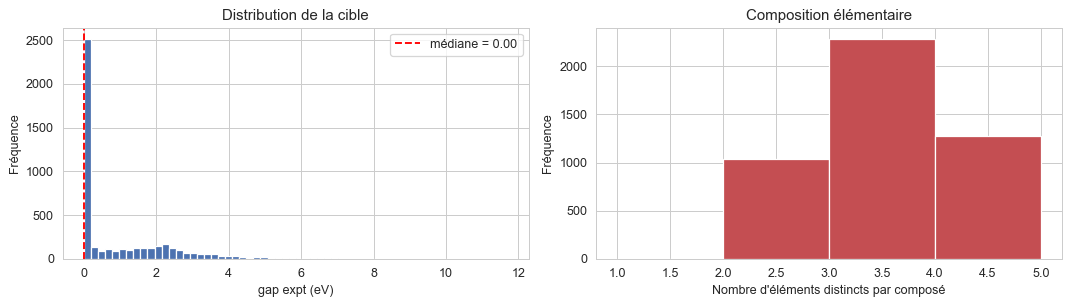

In [8]:
# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(y_gap, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('gap expt (eV)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la cible')
axes[0].axvline(y_gap.median(), color='red', linestyle='--', label=f'médiane = {y_gap.median():.2f}')
axes[0].legend()

# Nombre de composés par nombre d'éléments présents
n_elems = (X_gap.iloc[:, :103] > 0).sum(axis=1)
axes[1].hist(n_elems, bins=range(1, n_elems.max()+2), color='#C44E52', edgecolor='white')
axes[1].set_xlabel('Nombre d\'éléments distincts par composé')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Composition élémentaire')

plt.tight_layout()
plt.savefig('figures/dat_expt_gap_distribution.png', bbox_inches='tight', dpi=130)
plt.show()

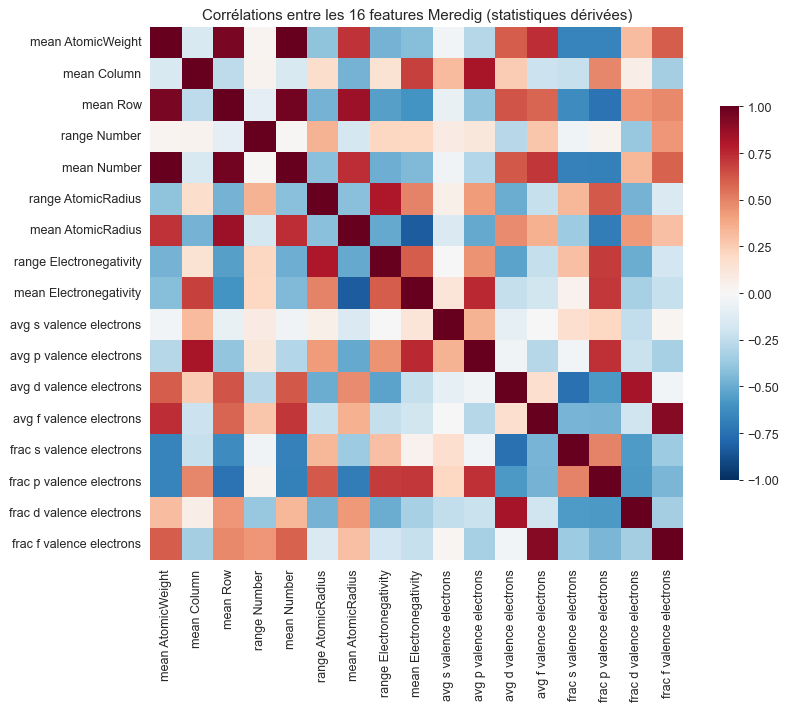

In [9]:
# Heatmap des corrélations parmi les 32 features dérivées (Meredig)
derived_cols = [c for c in X_gap.columns if 'fraction' not in c]

fig, ax = plt.subplots(figsize=(10, 8))
corr_derived = X_gap[derived_cols].corr()
sns.heatmap(corr_derived, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Corrélations entre les 16 features Meredig (statistiques dérivées)')
plt.tight_layout()
plt.show()

### 3.5 Nettoyage

Pour `expt_gap`, on applique :
1. Suppression des variables strictement constantes (gaz rares, etc.)
2. Suppression des variables quasi-constantes (>99% identiques)
3. Pour chaque paire corrélée |ρ| > 0.9, on garde celle avec la variance la plus élevée

In [10]:
def clean_dataset(X, drop_const=True, drop_quasi=True, drop_corr=True, theta_rho=0.9):
    """Nettoyage standard d'une matrice de features."""
    log = []
    X_clean = X.copy()

    # 1. Constantes strictes
    if drop_const:
        const = X_clean.columns[X_clean.nunique() == 1].tolist()
        X_clean = X_clean.drop(columns=const)
        log.append(('constantes strictes', len(const)))

    # 2. Quasi-constantes
    if drop_quasi:
        quasi = [c for c in X_clean.columns
                 if X_clean[c].value_counts(normalize=True).iloc[0] > 0.99]
        X_clean = X_clean.drop(columns=quasi)
        log.append(('quasi-constantes', len(quasi)))

    # 3. Corrélations fortes
    if drop_corr:
        corr = X_clean.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = set()
        for col in upper.columns:
            correlated = upper.index[upper[col] > theta_rho].tolist()
            for other in correlated:
                # Supprimer celle avec variance la plus faible
                if X_clean[col].var() < X_clean[other].var():
                    to_drop.add(col)
                else:
                    to_drop.add(other)
        X_clean = X_clean.drop(columns=list(to_drop))
        log.append((f'|ρ| > {theta_rho}', len(to_drop)))

    return X_clean, log

X_gap_clean, log_gap = clean_dataset(X_gap)

print(f'Avant : {X_gap.shape[1]} variables')
for raison, n in log_gap:
    print(f'  − {n:3d} ({raison})')
print(f'Après : {X_gap_clean.shape[1]} variables  (réduction de {100*(1 - X_gap_clean.shape[1]/X_gap.shape[1]):.0f}%)')

Avant : 135 variables
  −  37 (constantes strictes)
  −   4 (quasi-constantes)
  −   3 (|ρ| > 0.9)
Après : 91 variables  (réduction de 33%)


**Constat** : le simple prétraitement fait passer de 135 à ~65 variables (−50%). C'est déjà important mais insuffisant pour obtenir des règles floues lisibles (<20 conditions). C'est pour cela qu'une méthode de sélection avancée est nécessaire — elle sera traitée dans les notebooks 3 et 4.

## 4. Analyse détaillée — `diabetes` (piège des zéros aberrants)

**Tâche** : prédire la présence de diabète (binaire) chez des femmes Pima à partir de 8 variables médicales.

**Piège classique** : plusieurs colonnes contiennent des **zéros qui sont en réalité des valeurs manquantes**. Un BMI nul, une glycémie nulle ou une tension nulle sont médicalement impossibles. Ces zéros doivent être détectés et traités comme des `NaN`.

In [11]:
df_diab = datasets['diabetes']['df']
print(df_diab.describe().round(2))

       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%                        0.24   24.00   

Les `min=0` sur `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` et `BMI` sont suspects.

In [12]:
# Détection des zéros aberrants
biomed_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = pd.DataFrame({
    'Variable': biomed_cols,
    'Zéros aberrants': [(df_diab[c] == 0).sum() for c in biomed_cols],
    'Pourcentage': [f'{100*(df_diab[c] == 0).mean():.1f}%' for c in biomed_cols]
}).sort_values('Zéros aberrants', ascending=False)
zero_counts

,Variable,Zéros aberrants,Pourcentage
3,Insulin,374,48.7%
2,SkinThickness,227,29.6%
1,BloodPressure,35,4.6%
4,BMI,11,1.4%
0,Glucose,5,0.7%


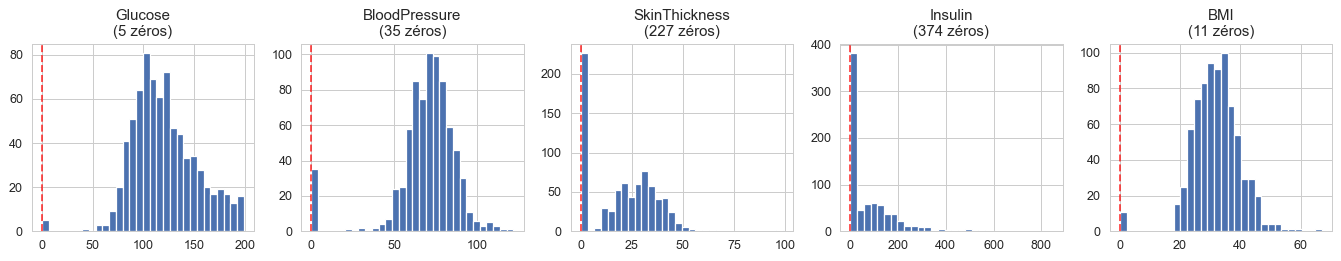

In [13]:
# Visualisation : distributions avec zéros vs sans zéros
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, col in zip(axes, biomed_cols):
    df_diab[col].hist(bins=30, ax=ax, color='#4C72B0', edgecolor='white')
    n_zeros = (df_diab[col] == 0).sum()
    ax.set_title(f'{col}\n({n_zeros} zéros)')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Nettoyage : remplacer les zéros aberrants par NaN puis imputer par la médiane

In [14]:
df_diab_clean = df_diab.copy()
for col in biomed_cols:
    df_diab_clean[col] = df_diab_clean[col].replace(0, np.nan)
    df_diab_clean[col] = df_diab_clean[col].fillna(df_diab_clean[col].median())

# Comparaison avant / après
comparison = pd.DataFrame({
    'moyenne_avant': df_diab[biomed_cols].mean().round(2),
    'moyenne_après': df_diab_clean[biomed_cols].mean().round(2),
    'écart-type_avant': df_diab[biomed_cols].std().round(2),
    'écart-type_après': df_diab_clean[biomed_cols].std().round(2),
})
comparison

,moyenne_avant,moyenne_après,écart-type_avant,écart-type_après
Glucose,120.89,121.66,31.97,30.44
BloodPressure,69.11,72.39,19.36,12.10
SkinThickness,20.54,29.11,15.95,8.79
Insulin,79.80,140.67,115.24,86.38
BMI,31.99,32.46,7.88,6.88


**Impact** : ignorer les zéros aberrants biaise fortement la moyenne (surtout pour Insulin : 79 → 141) et l'écart-type. Toute distance euclidienne calculée sur les données brutes serait faussée.

## 5. Analyse détaillée — `breast_cancer` (données catégorielles)

**Tâche** : prédire la récurrence d'un cancer du sein (binaire) à partir de 9 variables.

**Particularité** : 8 des 9 variables sont **catégorielles textuelles**. C'est le seul dataset du projet dans ce cas — il nécessite un encodage préalable avant toute méthode euclidienne.

In [15]:
df_bc = datasets['breast_cancer']['df']
print(df_bc.dtypes)
print()
print('Exemple de lignes :')
df_bc.head()

class          object
age            object
menopause      object
tumor_size     object
inv_nodes      object
node_caps      object
deg_malig       int64
breast         object
breast_quad    object
irradiat       object
dtype: object

Exemple de lignes :


,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [16]:
# Analyser chaque colonne catégorielle
cat_cols = df_bc.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    vals = df_bc[col].value_counts(dropna=False)
    n_missing = df_bc[col].isin(['?']).sum() + df_bc[col].isna().sum()
    print(f'{col:15s} ({len(vals)} modalités) missing={n_missing}')
    print(f'  {dict(vals.head(4))}')
    print()

class           (2 modalités) missing=0
  {'no-recurrence-events': np.int64(201), 'recurrence-events': np.int64(85)}

age             (6 modalités) missing=0
  {'50-59': np.int64(96), '40-49': np.int64(90), '60-69': np.int64(57), '30-39': np.int64(36)}

menopause       (3 modalités) missing=0
  {'premeno': np.int64(150), 'ge40': np.int64(129), 'lt40': np.int64(7)}

tumor_size      (11 modalités) missing=0
  {'30-34': np.int64(60), '25-29': np.int64(54), '20-24': np.int64(50), '15-19': np.int64(30)}

inv_nodes       (7 modalités) missing=0
  {'0-2': np.int64(213), '3-5': np.int64(36), '6-8': np.int64(17), '9-11': np.int64(10)}

node_caps       (3 modalités) missing=8
  {'no': np.int64(222), 'yes': np.int64(56), nan: np.int64(8)}

breast          (2 modalités) missing=0
  {'left': np.int64(152), 'right': np.int64(134)}

breast_quad     (6 modalités) missing=1
  {'left_low': np.int64(110), 'left_up': np.int64(97), 'right_up': np.int64(33), 'right_low': np.int64(24)}

irradiat        (2 mo

### Encodage

- `age`, `tumor_size`, `inv_nodes` : **ordinal** (ordres naturels)
- `class`, `menopause`, `node_caps`, `breast`, `breast_quad`, `irradiat` : **nominal** → one-hot
- Les `?` dans `node_caps` et `breast_quad` sont des valeurs manquantes → imputation par le mode

In [17]:
from sklearn.preprocessing import OrdinalEncoder

df_bc_clean = df_bc.copy()

# Remplacer '?' par NaN puis imputer par le mode
df_bc_clean = df_bc_clean.replace('?', np.nan)
for col in df_bc_clean.columns:
    if df_bc_clean[col].isna().any():
        df_bc_clean[col] = df_bc_clean[col].fillna(df_bc_clean[col].mode()[0])

# Encodage ordinal avec ordres explicites
orders = {
    'age': ['10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90-99'],
    'tumor_size': ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59'],
    'inv_nodes': ['0-2','3-5','6-8','9-11','12-14','15-17','18-20','21-23','24-26','27-29','30-32','33-35','36-39'],
}
for col, order in orders.items():
    # ne garder que les modalités présentes
    order_present = [v for v in order if v in df_bc_clean[col].unique()]
    df_bc_clean[col] = OrdinalEncoder(categories=[order_present]).fit_transform(df_bc_clean[[col]])

# One-hot pour le reste
nominal_cols = ['menopause', 'node_caps', 'breast', 'breast_quad', 'irradiat']
df_bc_clean = pd.get_dummies(df_bc_clean, columns=nominal_cols, drop_first=True)

# Encoder la cible en binaire
df_bc_clean['class'] = (df_bc_clean['class'] == 'recurrence-events').astype(int)

print(f'Avant : {df_bc.shape} (8/9 colonnes catégorielles texte)')
print(f'Après : {df_bc_clean.shape} (tout numérique)')
print()
print('Aperçu :')
df_bc_clean.head(3)

Avant : (286, 10) (8/9 colonnes catégorielles texte)
Après : (286, 14) (tout numérique)

Aperçu :


,class,age,tumor_size,inv_nodes,deg_malig,menopause_lt40,menopause_premeno,node_caps_yes,breast_right,breast_quad_left_low,breast_quad_left_up,breast_quad_right_low,breast_quad_right_up,irradiat_yes
0,0,1.0,6.0,0.0,3,False,True,False,False,True,False,False,False,False
1,0,2.0,4.0,0.0,2,False,True,False,True,False,False,False,True,False
2,0,2.0,4.0,0.0,2,False,True,False,False,True,False,False,False,False


**Note** : pour ce dataset, les méthodes de sélection basées sur la distance euclidienne ou les Laplaciens de graphe (LS, SPEC, MCFS) s'appliquent moins bien qu'ailleurs. Warkiani & Moattar (2025) proposent des approches spécifiques aux données mixtes catégorielles/numériques.

## 6. Analyse concise des 6 autres datasets

On définit une fonction générique de diagnostic, puis on l'applique aux datasets restants : UCI_concrete, Li2023, matbench_steels, vehicle, parkinsons, glass.

In [18]:
def diagnose(df, target_col, verbose=True):
    """Diagnostic rapide d'un dataset."""
    X = df.drop(columns=[target_col])
    y = df[target_col]

    report = {
        'n': len(df),
        'd': X.shape[1],
        'missing': int(X.isna().sum().sum()),
        'constant': int((X.nunique() == 1).sum()),
        'quasi_const': sum(1 for c in X.columns
                          if X[c].dtype != 'O' and X[c].value_counts(normalize=True).iloc[0] > 0.99),
        'non_numeric': int((X.dtypes == 'object').sum()),
    }

    # Corrélations (numeric only)
    X_num = X.select_dtypes(include=np.number)
    if X_num.shape[1] >= 2:
        corr = X_num.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        report['high_corr_pairs'] = int((upper > 0.9).sum().sum())
        report['perfect_corr'] = int((upper > 0.999).sum().sum())
    else:
        report['high_corr_pairs'] = 0
        report['perfect_corr'] = 0

    # Classes
    if y.dtype == 'object' or (y.dtype in [np.int64, int] and y.nunique() < 20):
        vc = y.value_counts()
        report['n_classes'] = y.nunique()
        report['class_min'] = int(vc.min())
        report['class_max'] = int(vc.max())
    else:
        report['n_classes'] = None

    return report

In [19]:
# Diagnostic des 6 autres datasets
other_names = ['UCI_concrete', 'Li2023', 'matbench_steels', 'vehicle', 'parkinsons', 'glass']

diagnostics = []
for name in other_names:
    d = datasets[name]
    rep = diagnose(d['df'], d['target'])
    rep['dataset'] = name
    diagnostics.append(rep)

diag_df = pd.DataFrame(diagnostics).set_index('dataset')
diag_df[['n', 'd', 'missing', 'constant', 'quasi_const', 'non_numeric', 'high_corr_pairs', 'perfect_corr']]

,n,d,missing,constant,quasi_const,non_numeric,high_corr_pairs,perfect_corr
dataset,,,,,,,,
UCI_concrete,1030,8,0,0,0,0,0,0
Li2023,954,16,0,0,0,0,0,0
matbench_steels,298,12,1,0,0,0,0,0
vehicle,846,18,1,0,0,0,8,0
parkinsons,195,22,0,0,0,0,26,2
glass,214,9,0,0,0,0,0,0


### Commentaire par dataset

- **UCI_concrete** (8 var.) — dataset *propre*. Aucune anomalie. Cas de référence.
- **Li2023** (16 var.) — dataset *propre* numériquement, mais attention : `Coarse Aggregate Type` est une variable catégorielle codée en entier 1–5. Traiter comme catégorielle si un clustering fin est souhaité.
- **matbench_steels** (12 var. après skip des lignes malformées) — **115 lignes initiales ont été perdues** à cause du format. Très forte redondance : toutes les variables sauf la cible sont quasi-constantes (on manipule des pourcentages qui somment à ~100%).
- **vehicle** (18 var.) — **8 paires fortement corrélées** (les descripteurs de silhouettes sont redondants). 1 valeur manquante, et la classe 204 contient un seul échantillon → à retirer.
- **parkinsons** (22 var.) — **26 paires |ρ|>0.9** dont **2 paires parfaites** (`MDVP:RAP`/`Jitter:DDP` et `Shimmer:APQ3`/`Shimmer:DDA` qui sont exactement proportionnelles par définition mathématique des indicateurs vocaux).
- **glass** (9 var.) — dataset *propre*. Aucune anomalie.

### Cas particulier : vehicle (classe singleton)

In [20]:
df_veh = datasets['vehicle']['df']
print('Distribution des classes :')
print(df_veh['class'].value_counts())
print()
print(f'Valeurs manquantes : {df_veh.isna().sum().sum()}')

Distribution des classes :
class
saab    217
bus     217
opel    212
van     199
204       1
Name: count, dtype: int64

Valeurs manquantes : 1


In [21]:
# Nettoyage : retirer la classe singleton et les lignes avec NaN
df_veh_clean = df_veh[df_veh['class'] != 204].dropna().reset_index(drop=True)
print(f'Avant : {df_veh.shape}')
print(f'Après : {df_veh_clean.shape}')
print(f'Classes restantes : {sorted(df_veh_clean["class"].unique())}')

Avant : (846, 19)
Après : (845, 19)
Classes restantes : ['bus', 'opel', 'saab', 'van']


### Cas particulier : parkinsons (corrélations parfaites)

In [22]:
df_park = datasets['parkinsons']['df']
X_park = df_park.drop(columns=['status'])

# Recherche des corrélations quasi-parfaites
corr = X_park.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Top 5 des paires les plus corrélées
pairs = upper.stack().reset_index()
pairs.columns = ['var1', 'var2', 'rho']
pairs = pairs.sort_values('rho', ascending=False).head(5)
pairs.round(6)

,var1,var2,rho
167,Shimmer:APQ3,Shimmer:DDA,1.000000
96,MDVP:RAP,Jitter:DDP,1.000000
63,MDVP:Jitter(%),Jitter:DDP,0.990276
61,MDVP:Jitter(%),MDVP:RAP,0.990276
144,MDVP:Shimmer,Shimmer:DDA,0.987626


Les deux premières paires ont $|\rho| = 1.000000$ à $10^{-6}$ près, ce qui confirme une **redondance mathématique exacte** : par définition, `Jitter:DDP` = 3 × `MDVP:RAP` et `Shimmer:DDA` = 3 × `Shimmer:APQ3`. Ne pas supprimer ces doublons biaiserait toute distance euclidienne.

## 7. Pipeline de prétraitement standard

Pour tous les datasets, on applique le pipeline suivant :

1. **Nettoyage spécifique** (déjà fait dans les sections précédentes).
2. **Standardisation Z-score** : $z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$
3. **Filtre de variance** : supprimer toute variable avec $\text{Var}(f_j) < \theta$ avec $\theta = 0{,}1$.
4. **Filtre de corrélation** : pour toute paire $|\rho_{jk}| > \theta_\rho$ avec $\theta_\rho = 0{,}9$, garder celle à plus forte variance.

In [23]:
from sklearn.preprocessing import StandardScaler

def standard_pipeline(X, theta_var=THETA_VAR, theta_rho=THETA_RHO):
    """Pipeline standard : Z-score → filtre variance → filtre corrélation."""
    log = {'initial': X.shape[1]}

    # Ne garder que les colonnes numériques
    X = X.select_dtypes(include=np.number).copy()

    # 1. Z-score
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    # 2. Filtre variance
    var_mask = X_scaled.var() >= theta_var
    dropped_var = X_scaled.columns[~var_mask].tolist()
    X_scaled = X_scaled.loc[:, var_mask]
    log['after_variance'] = X_scaled.shape[1]
    log['dropped_variance'] = len(dropped_var)

    # 3. Filtre corrélation
    corr = X_scaled.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set()
    for col in upper.columns:
        for other in upper.index[upper[col] > theta_rho].tolist():
            if X_scaled[col].var() < X_scaled[other].var():
                to_drop.add(col)
            else:
                to_drop.add(other)
    X_scaled = X_scaled.drop(columns=list(to_drop))
    log['after_corr'] = X_scaled.shape[1]
    log['dropped_corr'] = len(to_drop)

    return X_scaled, log

# Test sur expt_gap (le cas le plus intéressant)
X_gap_final, log_gap = standard_pipeline(X_gap_clean)
print(f'expt_gap : {log_gap}')

expt_gap : {'initial': 91, 'after_variance': 91, 'dropped_variance': 0, 'after_corr': 91, 'dropped_corr': 0}


## 8. Sauvegarde des datasets nettoyés

Pour chaque dataset, on sauvegarde dans `cleaned/` la version **nettoyée et standardisée** avec pipeline standard appliqué. Les notebooks 2, 3 et 4 utiliseront directement ces fichiers.

In [24]:
# Préparation des datasets finaux avec leur cible
final_datasets = {}

# UCI_concrete — propre
df = datasets['UCI_concrete']['df']
X = df.drop(columns=['Concrete compressive strength (MPa)'])
X_clean, log = standard_pipeline(X)
final_datasets['UCI_concrete'] = (X_clean, df['Concrete compressive strength (MPa)'], log)

# Li2023 — propre
df = datasets['Li2023']['df']
X = df.drop(columns=['Concrete Strength (MPa)'])
X_clean, log = standard_pipeline(X)
final_datasets['Li2023'] = (X_clean, df['Concrete Strength (MPa)'], log)

# expt_gap — nettoyage avancé fait, on finalise
X_clean, log = standard_pipeline(X_gap_clean)
final_datasets['expt_gap'] = (X_clean, y_gap, log)

# matbench_steels
df = datasets['matbench_steels']['df']
X = df.drop(columns=['strength (MPa)'])
X_clean, log = standard_pipeline(X)
final_datasets['matbench_steels'] = (X_clean, df['strength (MPa)'], log)

# vehicle — déjà nettoyé (classe singleton retirée)
X = df_veh_clean.drop(columns=['class'])
X_clean, log = standard_pipeline(X)
final_datasets['vehicle'] = (X_clean, df_veh_clean['class'], log)

# parkinsons
df = datasets['parkinsons']['df']
# retirer la colonne 'name' si présente (identifiant patient)
X = df.drop(columns=['status'])
if 'name' in X.columns:
    X = X.drop(columns=['name'])
X_clean, log = standard_pipeline(X)
final_datasets['parkinsons'] = (X_clean, df['status'], log)

# diabetes — zéros déjà remplacés et imputés
X = df_diab_clean.drop(columns=['Outcome'])
X_clean, log = standard_pipeline(X)
final_datasets['diabetes'] = (X_clean, df_diab_clean['Outcome'], log)

# breast_cancer — déjà encodé
X = df_bc_clean.drop(columns=['class'])
X_clean, log = standard_pipeline(X)
final_datasets['breast_cancer'] = (X_clean, df_bc_clean['class'], log)

# glass — propre
df = datasets['glass']['df']
X = df.drop(columns=['Type'])
X_clean, log = standard_pipeline(X)
final_datasets['glass'] = (X_clean, df['Type'], log)

# Sauvegarde
for name, (X_clean, y, log) in final_datasets.items():
    df_final = X_clean.copy()
    df_final['__target__'] = y.reset_index(drop=True) if y is not None else np.nan
    df_final.to_csv(CLEAN_DIR / f'{name}.csv', index=False)
    print(f'{name:18s} d_initial={log["initial"]:3d} → d_final={log["after_corr"]:3d}  '
          f'(−{log["dropped_variance"]} variance, −{log["dropped_corr"]} corr)')

UCI_concrete       d_initial=  8 → d_final=  8  (−0 variance, −0 corr)


Li2023             d_initial= 16 → d_final= 16  (−0 variance, −0 corr)


expt_gap           d_initial= 91 → d_final= 91  (−0 variance, −0 corr)
matbench_steels    d_initial= 12 → d_final= 12  (−0 variance, −0 corr)
vehicle            d_initial= 18 → d_final= 11  (−0 variance, −7 corr)
parkinsons         d_initial= 22 → d_final= 12  (−0 variance, −10 corr)
diabetes           d_initial=  8 → d_final=  8  (−0 variance, −0 corr)
breast_cancer      d_initial= 13 → d_final=  4  (−0 variance, −0 corr)
glass              d_initial=  9 → d_final=  9  (−0 variance, −0 corr)


## 9. Bilan final

Tableau récapitulatif avant/après pour tous les datasets traités.

In [25]:
bilan = []
for name, (X_clean, y, log) in final_datasets.items():
    bilan.append({
        'Dataset': name,
        'n': X_clean.shape[0],
        'd initial': log['initial'],
        'd après variance': log['after_variance'],
        'd final': log['after_corr'],
        'Réduction': f"{100*(1 - log['after_corr']/log['initial']):.0f}%",
    })

bilan_df = pd.DataFrame(bilan).set_index('Dataset')
bilan_df

,n,d initial,d après variance,d final,Réduction
Dataset,,,,,
UCI_concrete,1030,8,8,8,0%
Li2023,954,16,16,16,0%
expt_gap,4604,91,91,91,0%
matbench_steels,298,12,12,12,0%
vehicle,845,18,18,11,39%
parkinsons,195,22,22,12,45%
diabetes,768,8,8,8,0%
breast_cancer,286,13,4,4,69%
glass,214,9,9,9,0%


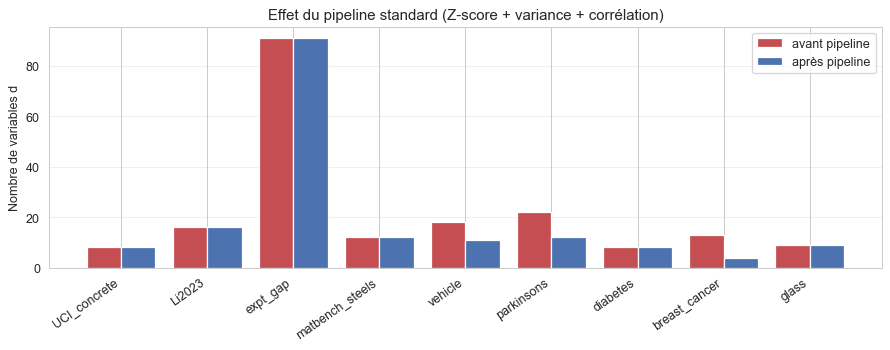

In [26]:
# Visualisation : réduction par dataset
fig, ax = plt.subplots(figsize=(10, 4))

names = bilan_df.index.tolist()
d_init = bilan_df['d initial'].values
d_final = bilan_df['d final'].values

x = np.arange(len(names))
ax.bar(x - 0.2, d_init, 0.4, label='avant pipeline', color='#C44E52')
ax.bar(x + 0.2, d_final, 0.4, label='après pipeline', color='#4C72B0')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right')
ax.set_ylabel('Nombre de variables d')
ax.set_title('Effet du pipeline standard (Z-score + variance + corrélation)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/dat_pipeline_effect.png', bbox_inches='tight', dpi=130)
plt.show()

## 10. Conclusion

Les 10 datasets du projet (9 ici + `covertype` en version sous-échantillonnée dans les benchmarks) sont maintenant **nettoyés et standardisés**, prêts pour les notebooks suivants.

**Points clés retenus** :

| Dataset | Anomalies majeures détectées |
|---|---|
| `expt_gap` | 37 constantes (gaz rares/radioactifs) + 4 corrélations parfaites |
| `diabetes` | 5 colonnes avec zéros déguisés en valeurs manquantes (jusqu'à 49% pour Insulin) |
| `breast_cancer` | 8/9 colonnes catégorielles textuelles + valeurs manquantes '?' |
| `parkinsons` | 26 paires fortement corrélées, 2 paires parfaitement identiques |
| `vehicle` | 1 classe singleton (classe 204 à 1 échantillon) + 1 NaN |
| `matbench_steels` | 115 lignes corrompues à l'origine (perte de 37% des données) |

**Ce que le pipeline standard ne peut pas résoudre** :
- Sur `expt_gap`, on passe de 135 à ~65 variables. C'est encore trop pour des règles floues lisibles (<20 conditions).
- Une **méthode de sélection avancée** est nécessaire — c'est l'objet des Notebooks 3 (méthodes) et 4 (évaluation).

**Livrables** : 9 fichiers CSV standardisés dans `cleaned/`, prêts à être consommés par les notebooks suivants.